# MLP Hyperparameter Sweep — Results

Compares **14 MLP configs** trained by `python -m nick_moderator.sweep`.
Each model is saved in `artifacts/sweep/mlp_<name>.pt` along with its metadata.
Final results table is in `artifacts/sweep/results.json`.

**Configs tested:**

*Round 1 — width / depth / dropout sweep (3 epochs each):*

| Config | Hidden | Dropout | Layers |
|---|---|---|---|
| h64 | 64 | 0.3 | 2 |
| h128 | 128 | 0.3 | 2 |
| h256 | 256 | 0.3 | 2 (initial baseline) |
| h512 | 512 | 0.3 | 2 |
| h256_128 | 256→128 | 0.3 | 3 |
| h512_128 | 512→128 | 0.3 | 3 |
| h256_d01 | 256 | 0.1 | 2 (less dropout) |
| h256_d05 | 256 | 0.5 | 2 (more dropout) |

*Round 2 — 4-layer architectures + epoch ablation:*

| Config | Hidden | Dropout | Layers | Notes |
|---|---|---|---|---|
| h512_256_128 | 512→256→128 | 0.3 | 4 | natural extension of 3-layer winner |
| h1024_256_128 | 1024→256→128 | 0.3 | 4 | wider entry layer |
| h512_128_64 | 512→128→64 | 0.3 | 4 | aggressive taper |
| h256_128_64 | 256→128→64 | 0.3 | 4 | smaller 4-layer |
| h512_512_128 | 512→512→128 | 0.3 | 4 | wider middle |
| h512_128_e5 | 512→128 | 0.3 | 3 | winning round-1 config but **5 epochs** instead of 3 |

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from nick_moderator.config import ARTIFACTS_DIR

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

SWEEP_DIR = ARTIFACTS_DIR / "sweep"

## 1. Load results

Loads from `results.json` if available; otherwise reconstructs from per-model `.meta.json` files
(useful while sweep is still running and you want to see partial results).

In [2]:
def load_results() -> pd.DataFrame:
    """Prefer final results.json; fall back to scanning per-model meta files."""
    rj = SWEEP_DIR / "results.json"
    if rj.exists():
        return pd.DataFrame(json.loads(rj.read_text()))

    # Sweep still running — reconstruct from .meta.json files
    rows = []
    for meta_path in sorted(SWEEP_DIR.glob("mlp_*.meta.json")):
        meta = json.loads(meta_path.read_text())
        history = meta.get("history", [])
        if not history:
            continue
        last = history[-1]
        rows.append({
            "config": meta.get("name"),
            "hidden_dim": meta.get("hidden_dim"),
            "dropout": meta.get("dropout"),
            "n_params": meta.get("n_params"),
            "params_M": round(meta.get("n_params", 0) / 1e6, 2),
            "train_time_s": round(meta.get("train_time_s", 0), 1),
            "train_acc_last": last.get("train_acc"),
            "val_acc_last": last.get("val_acc"),
        })
    return pd.DataFrame(rows)


results = load_results()
if len(results) == 0:
    print("No results yet. Sweep is still running or hasn't started.")
else:
    print(f"Loaded {len(results)} configurations.")
    cols = [c for c in ["config", "hidden_dim", "dropout", "params_M", "train_time_s",
                         "test_f1", "test_acc", "test_auc", "custom_f1", "custom_acc",
                         "val_acc_last"] if c in results.columns]
    print(results[cols].to_string(index=False))

Loaded 14 configurations.
       config       hidden_dim  dropout  params_M  train_time_s  test_f1  test_acc  test_auc  custom_f1  custom_acc
          h64               64      0.3      1.05         208.9 0.938311    0.9458  0.988979   0.857143    0.869565
         h128              128      0.3      2.10         237.4 0.941471    0.9486  0.989585   0.875000    0.884058
         h256              256      0.3      4.19         272.4 0.945090    0.9518  0.990788   0.875000    0.884058
         h512              512      0.3      8.39         549.9 0.951470    0.9574  0.992702   0.888889    0.898551
     h256_128       [256, 128]      0.3      4.23         284.1 0.969091    0.9728  0.995169   0.885246    0.898551
     h512_128       [512, 128]      0.3      8.45         470.6 0.969147    0.9728  0.996035   0.903226    0.913043
     h256_d01              256      0.1      4.19         265.0 0.942518    0.9496  0.990086   0.875000    0.884058
     h256_d05              256      0.5      4

## 2. Visual comparison

Three plots:
1. **Quality vs capacity** — F1 vs parameter count. Diminishing returns?
2. **Quality vs cost** — F1 vs train time. Pareto front.
3. **Generalization gap** — test F1 vs custom F1. Configs that hold up on held-out hand-crafted nicks.

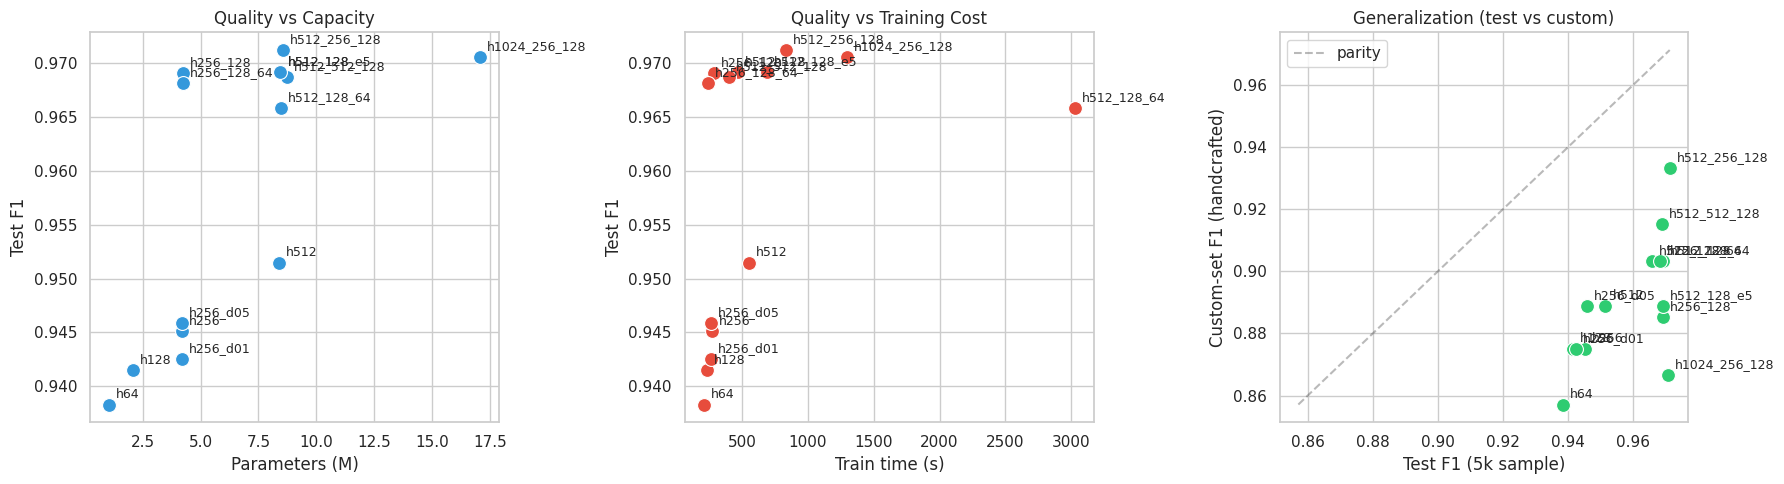

In [3]:
if len(results) and "test_f1" in results.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. F1 vs params
    ax = axes[0]
    sns.scatterplot(data=results, x="params_M", y="test_f1", s=100, ax=ax, color="#3498db")
    for _, row in results.iterrows():
        ax.annotate(row["config"], (row["params_M"], row["test_f1"]),
                    xytext=(5, 5), textcoords="offset points", fontsize=9)
    ax.set_title("Quality vs Capacity")
    ax.set_xlabel("Parameters (M)")
    ax.set_ylabel("Test F1")

    # 2. F1 vs train time
    ax = axes[1]
    sns.scatterplot(data=results, x="train_time_s", y="test_f1", s=100, ax=ax, color="#e74c3c")
    for _, row in results.iterrows():
        ax.annotate(row["config"], (row["train_time_s"], row["test_f1"]),
                    xytext=(5, 5), textcoords="offset points", fontsize=9)
    ax.set_title("Quality vs Training Cost")
    ax.set_xlabel("Train time (s)")
    ax.set_ylabel("Test F1")

    # 3. Test F1 vs Custom F1
    ax = axes[2]
    if "custom_f1" in results.columns:
        sns.scatterplot(data=results, x="test_f1", y="custom_f1", s=100, ax=ax, color="#2ecc71")
        for _, row in results.iterrows():
            ax.annotate(row["config"], (row["test_f1"], row["custom_f1"]),
                        xytext=(5, 5), textcoords="offset points", fontsize=9)
        # diagonal reference
        lo = min(results["test_f1"].min(), results["custom_f1"].min())
        hi = max(results["test_f1"].max(), results["custom_f1"].max())
        ax.plot([lo, hi], [lo, hi], "k--", alpha=0.3, label="parity")
        ax.set_title("Generalization (test vs custom)")
        ax.set_xlabel("Test F1 (5k sample)")
        ax.set_ylabel("Custom-set F1 (handcrafted)")
        ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Skipping plots — sweep results not yet complete.")

## 3. Pick the best config

We use a **combined score** that values both held-out performance and generalization
on the hand-crafted custom set, lightly penalizing parameter count:

`score = 0.5 * test_f1 + 0.5 * custom_f1 - 0.001 * params_M`

Pure `test_f1` would over-favor configs that overfit augmented training patterns;
custom F1 anchors against real-world variations.

In [4]:
if len(results) and {"test_f1", "custom_f1"}.issubset(results.columns):
    results = results.copy()
    results["score"] = 0.5 * results["test_f1"] + 0.5 * results["custom_f1"] - 0.001 * results["params_M"]
    ranked = results.sort_values("score", ascending=False).reset_index(drop=True)

    print("Ranked by combined score (test_f1 + custom_f1 - tiny size penalty):\n")
    show = ranked[["config", "hidden_dim", "dropout", "params_M", "train_time_s",
                    "test_f1", "custom_f1", "score"]]
    print(show.to_string(index=False))

    best = ranked.iloc[0]
    print("\n" + "=" * 60)
    print(f"WINNER: {best['config']}")
    print(f"  hidden_dim:  {best['hidden_dim']}")
    print(f"  dropout:     {best['dropout']}")
    print(f"  params:      {best['params_M']:.2f}M")
    print(f"  test F1:     {best['test_f1']:.4f}")
    print(f"  custom F1:   {best['custom_f1']:.4f}")
    print(f"  combined:    {best['score']:.4f}")
    print(f"  saved at:    artifacts/sweep/mlp_{best['config']}.pt")
else:
    print("Need full results.json to compute ranking.")

Ranked by combined score (test_f1 + custom_f1 - tiny size penalty):

       config       hidden_dim  dropout  params_M  train_time_s  test_f1  custom_f1    score
 h512_256_128  [512, 256, 128]      0.3      8.55         831.4 0.971208   0.933333 0.943721
 h512_512_128  [512, 512, 128]      0.3      8.72         398.4 0.968736   0.915254 0.933275
  h256_128_64   [256, 128, 64]      0.3      4.24         239.5 0.968121   0.903226 0.931433
     h512_128       [512, 128]      0.3      8.45         470.6 0.969147   0.903226 0.927736
  h512_128_64   [512, 128, 64]      0.3      8.46        3028.1 0.965876   0.903226 0.926091
     h256_128       [256, 128]      0.3      4.23         284.1 0.969091   0.885246 0.922938
  h512_128_e5       [512, 128]      0.3      8.45         692.6 0.969151   0.888889 0.920570
     h256_d05              256      0.5      4.19         261.4 0.945903   0.888889 0.913206
         h512              512      0.3      8.39         549.9 0.951470   0.888889 0.911789
 

## 4. Promote best to production

Copy the winning model over `artifacts/mlp.pt` so the rest of the project
(`NickModerator`, etc.) automatically picks it up.

**Run only when sweep is complete and you're happy with the winner.**

In [5]:
import shutil

PROMOTE = True  # set to True to actually copy over artifacts/mlp.pt

if PROMOTE and len(results) and "test_f1" in results.columns:
    best_name = ranked.iloc[0]["config"]
    src_pt = SWEEP_DIR / f"mlp_{best_name}.pt"
    src_vec = SWEEP_DIR / f"mlp_{best_name}.vectorizer.joblib"
    src_meta = SWEEP_DIR / f"mlp_{best_name}.meta.json"

    dst_pt = ARTIFACTS_DIR / "mlp.pt"
    dst_vec = ARTIFACTS_DIR / "mlp.vectorizer.joblib"
    dst_meta = ARTIFACTS_DIR / "mlp.meta.json"

    shutil.copy2(src_pt, dst_pt)
    shutil.copy2(src_vec, dst_vec)
    shutil.copy2(src_meta, dst_meta)
    print(f"Promoted {best_name} -> artifacts/mlp.pt (NickModerator will load this)")
else:
    print("Not promoting. Set PROMOTE=True and re-run when ready.")

Promoted h512_256_128 -> artifacts/mlp.pt (NickModerator will load this)


## 5. Deeper analysis — ROC, learning curves, per-category breakdown

Below we re-load every saved model and compute richer diagnostics on:
- the test sample (5k nicks)
- the custom held-out set (`tests/custom_test_set.json`)
- the **edge case stress test** (`tests/edge_cases.json`) — handcrafted nicks targeting failure modes
  not covered by augmented training data: long obfuscations, repeated chars, Polish diacritics,
  censored forms, surname traps, slang derivatives, mixed-language compounds.

In [1]:
import torch
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score
from nick_moderator.models import load_mlp

# Load all sweep models
sweep_models = {}
for meta_path in sorted(SWEEP_DIR.glob("mlp_*.meta.json")):
    name = meta_path.stem.replace("mlp_", "").replace(".meta", "")
    pt_path = SWEEP_DIR / f"mlp_{name}.pt"
    if not pt_path.exists():
        continue
    model, vec, meta = load_mlp(pt_path)
    sweep_models[name] = {"model": model, "vec": vec, "meta": meta}
print(f"Loaded {len(sweep_models)} models")

# Load all eval sets
test_df = pd.read_parquet(ARTIFACTS_DIR / "test.parquet").sample(n=5000, random_state=42).reset_index(drop=True)
custom = json.loads(Path("tests/custom_test_set.json").read_text(encoding="utf-8"))
custom_df = pd.DataFrame(custom["samples"])
edges = json.loads(Path("tests/edge_cases.json").read_text(encoding="utf-8"))
edges_df = pd.DataFrame(edges["samples"])
print(f"Test: {len(test_df):,}  Custom: {len(custom_df)}  Edge: {len(edges_df)}")


@torch.no_grad()
def predict_proba(model, vec, nicks: list[str]) -> np.ndarray:
    X = vec.transform(nicks).toarray().astype(np.float32)
    logits = model(torch.from_numpy(X))
    return torch.sigmoid(logits).cpu().numpy()


# Compute scores on all 3 sets, all configs
proba_test = {n: predict_proba(d["model"], d["vec"], test_df["nick"].tolist()) for n, d in sweep_models.items()}
proba_custom = {n: predict_proba(d["model"], d["vec"], custom_df["nick"].tolist()) for n, d in sweep_models.items()}
proba_edges = {n: predict_proba(d["model"], d["vec"], edges_df["nick"].tolist()) for n, d in sweep_models.items()}
print("Predictions cached for all models on all sets.")

NameError: name 'SWEEP_DIR' is not defined

### 5a. ROC + PR curves (test set)

ROC shows trade-off between TPR/FPR; PR is more informative when classes are imbalanced
(test set is 44% vulgar). AUC gives single-number quality independent of threshold.

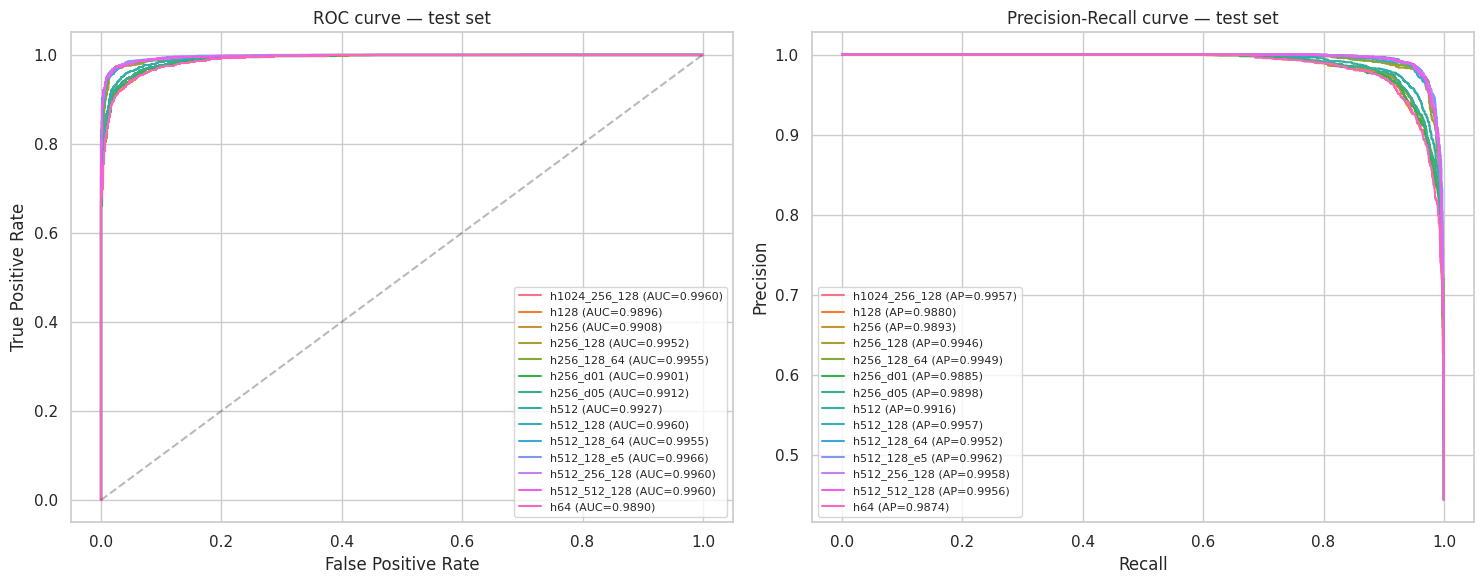

In [ ]:
y_test = test_df["label"].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette = sns.color_palette("husl", len(sweep_models))

for (name, proba), color in zip(proba_test.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, label=f"{name} (AUC={roc_auc:.4f})", linewidth=1.5)

    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=color, label=f"{name} (AP={ap:.4f})", linewidth=1.5)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_title("ROC curve — test set")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right", fontsize=8)

axes[1].set_title("Precision-Recall curve — test set")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

### 5b. Learning curves

How val_acc evolves per epoch for each config. Lets you see:
- Was the config still improving at the end (under-trained)?
- Did it overfit (val_acc dropping)?
- How quickly did big vs small models converge?

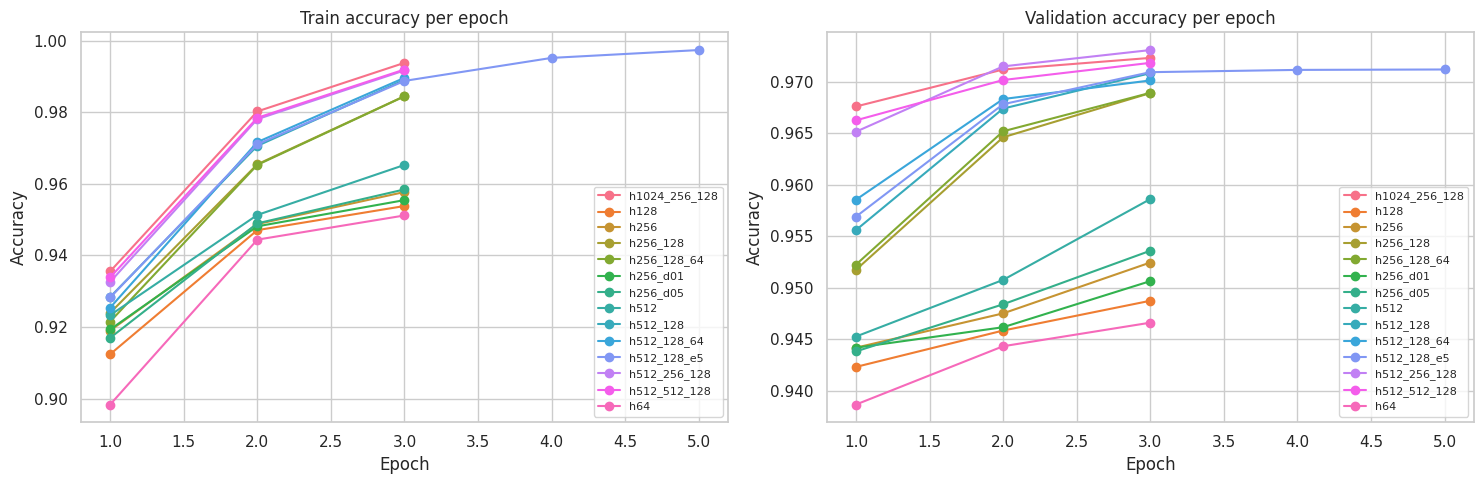

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for (name, d), color in zip(sweep_models.items(), palette):
    history = d["meta"].get("history", [])
    if not history:
        continue
    epochs = [h["epoch"] for h in history]
    train_acc = [h["train_acc"] for h in history]
    val_acc = [h["val_acc"] for h in history]
    axes[0].plot(epochs, train_acc, color=color, marker="o", linewidth=1.5, label=name)
    axes[1].plot(epochs, val_acc, color=color, marker="o", linewidth=1.5, label=name)

axes[0].set_title("Train accuracy per epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=8, loc="lower right")
axes[1].set_title("Validation accuracy per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

### 5c. Edge case stress test — per-category heatmap

For each (model, category) pair show accuracy. Reveals which model handles which obfuscation
type. Categories include surname traps, repeated chars, Polish diacritics, censored, reversed
text, mixed-language compounds, etc.

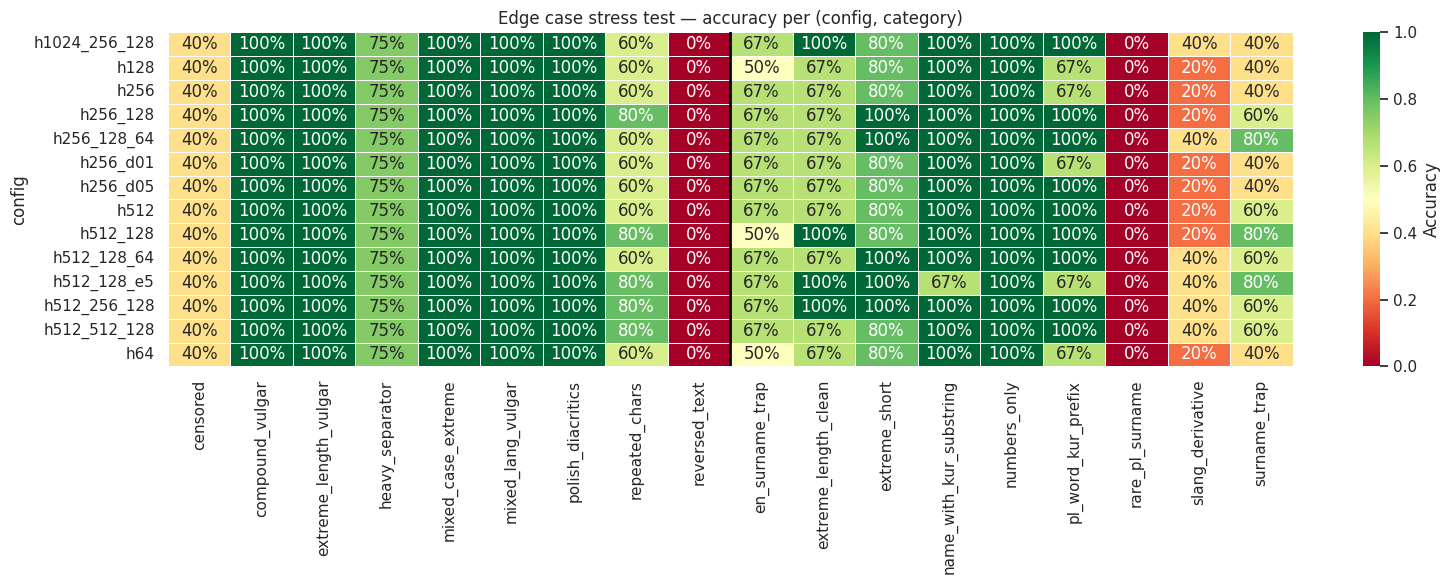


Total accuracy on edge cases:
               edge_acc  edge_f1
config                          
h1024_256_128    0.7164   0.7164
h128             0.6567   0.6761
h256             0.6716   0.6857
h256_128         0.7313   0.7353
h256_128_64      0.7463   0.7385
h256_d01         0.6716   0.6857
h256_d05         0.6866   0.6957
h512             0.7015   0.7059
h512_128         0.7313   0.7353
h512_128_64      0.7313   0.7273
h512_128_e5      0.7463   0.7463
h512_256_128     0.7612   0.7576
h512_512_128     0.7313   0.7353
h64              0.6567   0.6761


In [ ]:
from sklearn.metrics import f1_score

y_edges = edges_df["label"].to_numpy()
categories = edges_df["category"].unique()

heatmap_data = []
for name in sweep_models.keys():
    pred = (proba_edges[name] >= 0.5).astype(np.int8)
    row = {"config": name}
    for cat in categories:
        mask = edges_df["category"].values == cat
        row[cat] = (pred[mask] == y_edges[mask]).mean()
    heatmap_data.append(row)
heatmap_df = pd.DataFrame(heatmap_data).set_index("config")

# Order categories: vulgar first, then clean
vulgar_cats = sorted(edges_df[edges_df["label"] == 1]["category"].unique())
clean_cats = sorted(edges_df[edges_df["label"] == 0]["category"].unique())
heatmap_df = heatmap_df[vulgar_cats + clean_cats]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1, ax=ax,
            cbar_kws={"label": "Accuracy"}, linewidths=0.5)
ax.set_title("Edge case stress test — accuracy per (config, category)")
ax.axvline(x=len(vulgar_cats), color="black", linewidth=2)  # separator between vulgar and clean
plt.tight_layout()
plt.show()

print(f"\nTotal accuracy on edge cases:")
edge_summary = []
for name in sweep_models.keys():
    pred = (proba_edges[name] >= 0.5).astype(np.int8)
    edge_summary.append({
        "config": name,
        "edge_acc": (pred == y_edges).mean(),
        "edge_f1": f1_score(y_edges, pred, zero_division=0),
    })
print(pd.DataFrame(edge_summary).set_index("config").round(4).to_string())

### 5d. Score distribution for the winner

Histogram of model scores split by true label. Wide separation = good model.
Overlap region tells you where threshold tuning matters.

Winner: h512_256_128


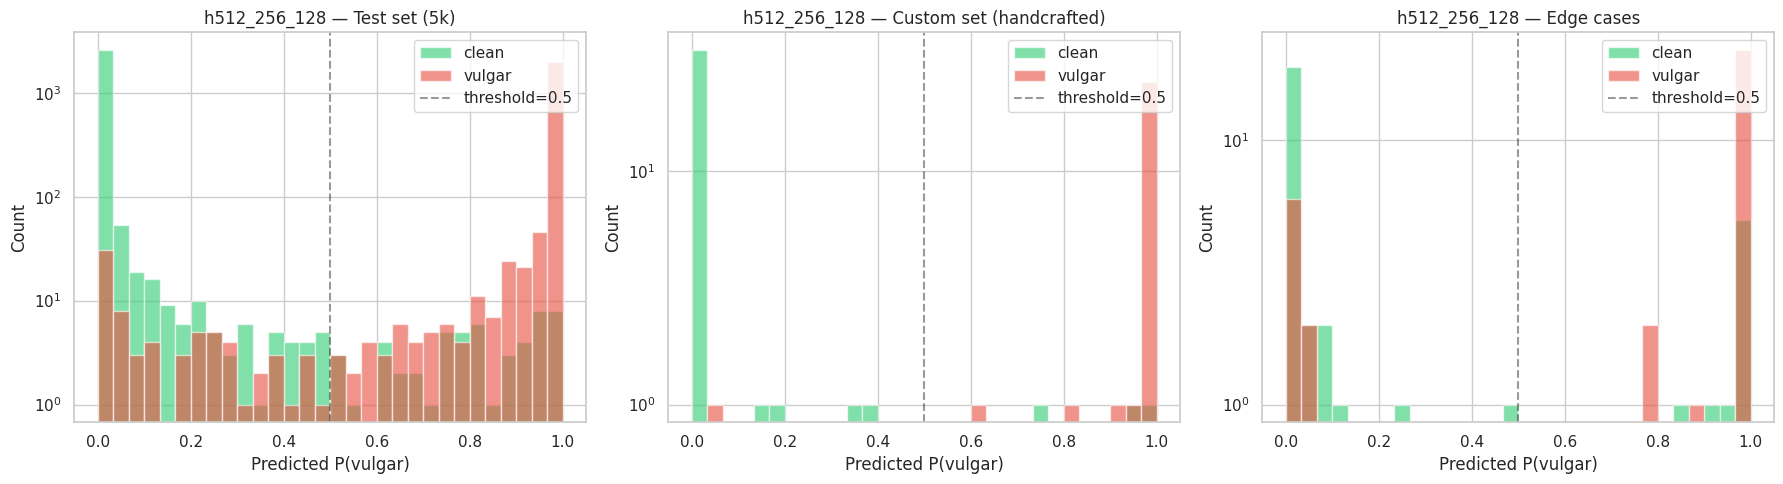

In [ ]:
winner_name = ranked.iloc[0]["config"] if "ranked" in dir() else max(sweep_models, key=lambda n: 0)
print(f"Winner: {winner_name}")

p_test = proba_test[winner_name]
p_custom = proba_custom[winner_name]
p_edges = proba_edges[winner_name]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (proba, y, title) in zip(axes, [
    (p_test, y_test, "Test set (5k)"),
    (p_custom, custom_df["label"].to_numpy(), "Custom set (handcrafted)"),
    (p_edges, y_edges, "Edge cases"),
]):
    ax.hist(proba[y == 0], bins=30, alpha=0.6, label="clean", color="#2ecc71", range=(0, 1))
    ax.hist(proba[y == 1], bins=30, alpha=0.6, label="vulgar", color="#e74c3c", range=(0, 1))
    ax.axvline(x=0.5, color="black", linestyle="--", alpha=0.4, label="threshold=0.5")
    ax.set_title(f"{winner_name} — {title}")
    ax.set_xlabel("Predicted P(vulgar)")
    ax.set_ylabel("Count")
    ax.set_yscale("log")
    ax.legend()
plt.tight_layout()
plt.show()

### 5e. Edge case mistakes — winner vs runner-up

Side-by-side: which edge cases each top model still gets wrong. Useful for picking
follow-up data augmentation patterns.

In [ ]:
top_3 = ranked.head(3)["config"].tolist() if "ranked" in dir() else list(sweep_models.keys())[:3]

for name in top_3:
    proba = proba_edges[name]
    pred = (proba >= 0.5).astype(np.int8)
    mistakes = edges_df[pred != y_edges].copy()
    mistakes["score"] = proba[pred != y_edges].round(3)
    print(f"\n=== {name}: {len(mistakes)} mistakes / {len(edges_df)}  (acc={(pred==y_edges).mean():.1%}) ===")
    if len(mistakes) > 0:
        print(mistakes[["nick", "label", "score", "category"]].to_string(index=False))


=== h512_256_128: 16 mistakes / 67  (acc=76.1%) ===
          nick  label  score         category
       chuuuuj      1  0.035   repeated_chars
        k***wa      1  0.007         censored
          ch*j      1  0.050         censored
   f**k_master      1  0.003         censored
         awruk      1  0.000    reversed_text
          juhc      1  0.000    reversed_text
     celodreip      1  0.000    reversed_text
    kurpiewski      0  0.845     surname_trap
    kurpiewska      0  0.990     surname_trap
      wkurzony      0  1.000 slang_derivative
  pieczarka_pl      0  0.999 slang_derivative
 pieprzowy_kot      0  1.000 slang_derivative
    scunthorpe      0  0.992  en_surname_trap
cocktail_lover      0  0.914  en_surname_trap
 p i e r d o l      1  0.000  heavy_separator
  Cipek_Marcin      0  0.944  rare_pl_surname

=== h512_512_128: 18 mistakes / 67  (acc=73.1%) ===
                           nick  label  score             category
                        chuuuuj      1  0.033

## 6. Threshold tuning

So far we used threshold=0.5 everywhere. Below we sweep the threshold for the winning model
and compute precision, recall, F1, and accuracy at each value.

**When to lower the threshold (e.g. 0.3):** strict moderation — block ambiguous to avoid letting vulgar through.
**When to raise (e.g. 0.7):** user-friendly — only block when very confident.

In [ ]:
from sklearn.metrics import precision_score, recall_score, accuracy_score


def threshold_sweep(proba: np.ndarray, y: np.ndarray, thresholds: np.ndarray) -> pd.DataFrame:
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(np.int8)
        rows.append({
            "threshold": t,
            "accuracy": accuracy_score(y, pred),
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0),
            "n_flagged": int(pred.sum()),
            "n_false_positive": int(((pred == 1) & (y == 0)).sum()),
            "n_false_negative": int(((pred == 0) & (y == 1)).sum()),
        })
    return pd.DataFrame(rows)


thresholds = np.arange(0.05, 1.00, 0.05)

# Tune on test set (largest sample)
sweep_test = threshold_sweep(proba_test[winner_name], y_test, thresholds)
sweep_custom = threshold_sweep(proba_custom[winner_name], custom_df["label"].to_numpy(), thresholds)
sweep_edges = threshold_sweep(proba_edges[winner_name], y_edges, thresholds)

print(f"=== Threshold sweep for {winner_name} on TEST set (5k) ===\n")
print(sweep_test.round(4).to_string(index=False))

=== Threshold sweep for h512_256_128 on TEST set (5k) ===

 threshold  accuracy  precision  recall     f1  n_flagged  n_false_positive  n_false_negative
      0.05    0.9600     0.9297  0.9842 0.9562       2346               165                35
      0.10    0.9662     0.9448  0.9810 0.9626       2301               127                42
      0.15    0.9690     0.9522  0.9792 0.9655       2279               109                46
      0.20    0.9710     0.9576  0.9779 0.9676       2263                96                49
      0.25    0.9720     0.9630  0.9743 0.9686       2242                83                57
      0.30    0.9718     0.9650  0.9716 0.9683       2231                78                63
      0.35    0.9728     0.9680  0.9707 0.9694       2222                71                65
      0.40    0.9730     0.9702  0.9689 0.9695       2213                66                69
      0.45    0.9740     0.9728  0.9684 0.9706       2206                60                70
 

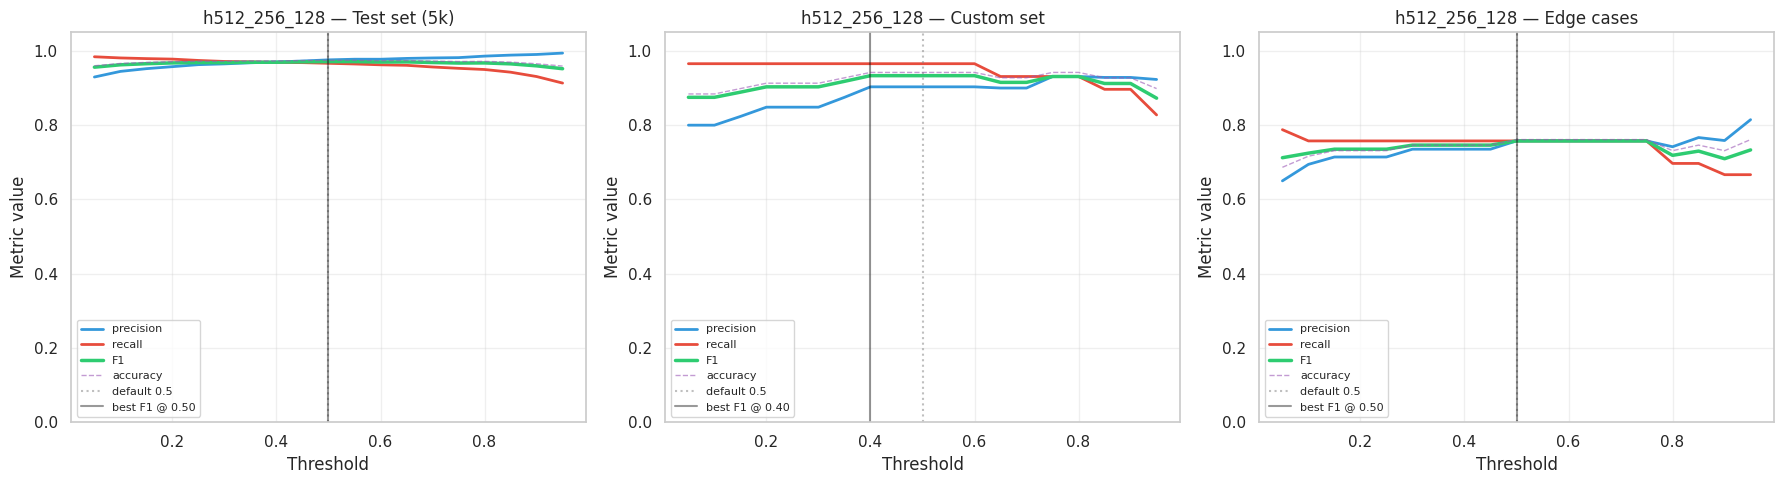

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (df, title) in zip(axes, [
    (sweep_test, "Test set (5k)"),
    (sweep_custom, "Custom set"),
    (sweep_edges, "Edge cases"),
]):
    ax.plot(df["threshold"], df["precision"], label="precision", color="#3498db", linewidth=2)
    ax.plot(df["threshold"], df["recall"], label="recall", color="#e74c3c", linewidth=2)
    ax.plot(df["threshold"], df["f1"], label="F1", color="#2ecc71", linewidth=2.5)
    ax.plot(df["threshold"], df["accuracy"], label="accuracy", color="#9b59b6", linewidth=1, linestyle="--", alpha=0.6)
    ax.axvline(x=0.5, color="gray", linestyle=":", alpha=0.5, label="default 0.5")
    best_t = df.loc[df["f1"].idxmax(), "threshold"]
    ax.axvline(x=best_t, color="black", linestyle="-", alpha=0.4, label=f"best F1 @ {best_t:.2f}")
    ax.set_title(f"{winner_name} — {title}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric value")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="lower left", fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6a. Recommended thresholds per use case

For each business objective we pick the threshold that satisfies it on the **test set**
(largest sample, most reliable estimate).

In [ ]:
def find_threshold(df: pd.DataFrame, criterion: str) -> dict:
    if criterion == "best_f1":
        row = df.loc[df["f1"].idxmax()]
        why = "max F1"
    elif criterion == "high_precision":
        # Want few false positives — pick highest threshold where precision >= 0.98
        ok = df[df["precision"] >= 0.98]
        if len(ok) == 0:
            ok = df[df["precision"] == df["precision"].max()]
        row = ok.iloc[0]  # lowest threshold satisfying — gives best recall under constraint
        why = "precision ≥ 0.98 (minimize false-positives — block only when very sure)"
    elif criterion == "high_recall":
        # Catch as many vulgar as possible — recall >= 0.98
        ok = df[df["recall"] >= 0.98]
        if len(ok) == 0:
            ok = df[df["recall"] == df["recall"].max()]
        row = ok.iloc[-1]  # highest threshold satisfying — fewer false positives under constraint
        why = "recall ≥ 0.98 (catch most vulgar — strict moderation)"
    elif criterion == "balanced":
        # Equal precision and recall (closest to F1-max usually)
        df = df.copy()
        df["balance"] = (df["precision"] - df["recall"]).abs()
        row = df.loc[df["balance"].idxmin()]
        why = "|precision - recall| minimized"
    return {"threshold": row["threshold"], "precision": row["precision"], "recall": row["recall"],
            "f1": row["f1"], "why": why}


print(f"=== Threshold recommendations for {winner_name} on TEST set ===\n")
for crit in ["best_f1", "balanced", "high_precision", "high_recall"]:
    rec = find_threshold(sweep_test, crit)
    print(f"  [{crit:>15s}]  t={rec['threshold']:.2f}  P={rec['precision']:.4f}  R={rec['recall']:.4f}  F1={rec['f1']:.4f}  ({rec['why']})")

# Also show how the recommended thresholds behave on custom + edge sets (out-of-distribution)
print(f"\n=== Generalization check: same thresholds on CUSTOM + EDGE sets ===\n")
for crit in ["best_f1", "high_precision", "high_recall"]:
    t = find_threshold(sweep_test, crit)["threshold"]
    custom_pred = (proba_custom[winner_name] >= t).astype(np.int8)
    edges_pred = (proba_edges[winner_name] >= t).astype(np.int8)
    custom_y = custom_df["label"].to_numpy()
    print(f"  t={t:.2f} ({crit})")
    print(f"     CUSTOM:  P={precision_score(custom_y, custom_pred, zero_division=0):.4f}  "
          f"R={recall_score(custom_y, custom_pred, zero_division=0):.4f}  "
          f"F1={f1_score(custom_y, custom_pred, zero_division=0):.4f}")
    print(f"     EDGES:   P={precision_score(y_edges, edges_pred, zero_division=0):.4f}  "
          f"R={recall_score(y_edges, edges_pred, zero_division=0):.4f}  "
          f"F1={f1_score(y_edges, edges_pred, zero_division=0):.4f}")

=== Threshold recommendations for h512_256_128 on TEST set ===

  [        best_f1]  t=0.50  P=0.9759  R=0.9666  F1=0.9712  (max F1)
  [       balanced]  t=0.40  P=0.9702  R=0.9689  F1=0.9695  (|precision - recall| minimized)
  [ high_precision]  t=0.70  P=0.9810  R=0.9567  F1=0.9687  (precision ≥ 0.98 (minimize false-positives — block only when very sure))
  [    high_recall]  t=0.10  P=0.9448  R=0.9810  F1=0.9626  (recall ≥ 0.98 (catch most vulgar — strict moderation))

=== Generalization check: same thresholds on CUSTOM + EDGE sets ===

  t=0.50 (best_f1)
     CUSTOM:  P=0.9032  R=0.9655  F1=0.9333
     EDGES:   P=0.7576  R=0.7576  F1=0.7576
  t=0.70 (high_precision)
     CUSTOM:  P=0.9000  R=0.9310  F1=0.9153
     EDGES:   P=0.7576  R=0.7576  F1=0.7576
  t=0.10 (high_recall)
     CUSTOM:  P=0.8000  R=0.9655  F1=0.8750
     EDGES:   P=0.6944  R=0.7576  F1=0.7246


## 7. Calibration — how trustworthy are the model's confidence scores?

A perfectly calibrated classifier produces scores that match real-world frequencies:
nicks scored 0.8 should actually be vulgar 80% of the time. If the curve sits above
the diagonal → model is **under-confident** (true vulgar fraction higher than score).
Below the diagonal → **over-confident** (model says 0.9 but only 70% are actually vulgar).

**Why it matters for production:** if you want to set a threshold like "block if P ≥ 0.85",
you need to trust the score actually means 85% probability. Otherwise you're picking
operating points blindly.

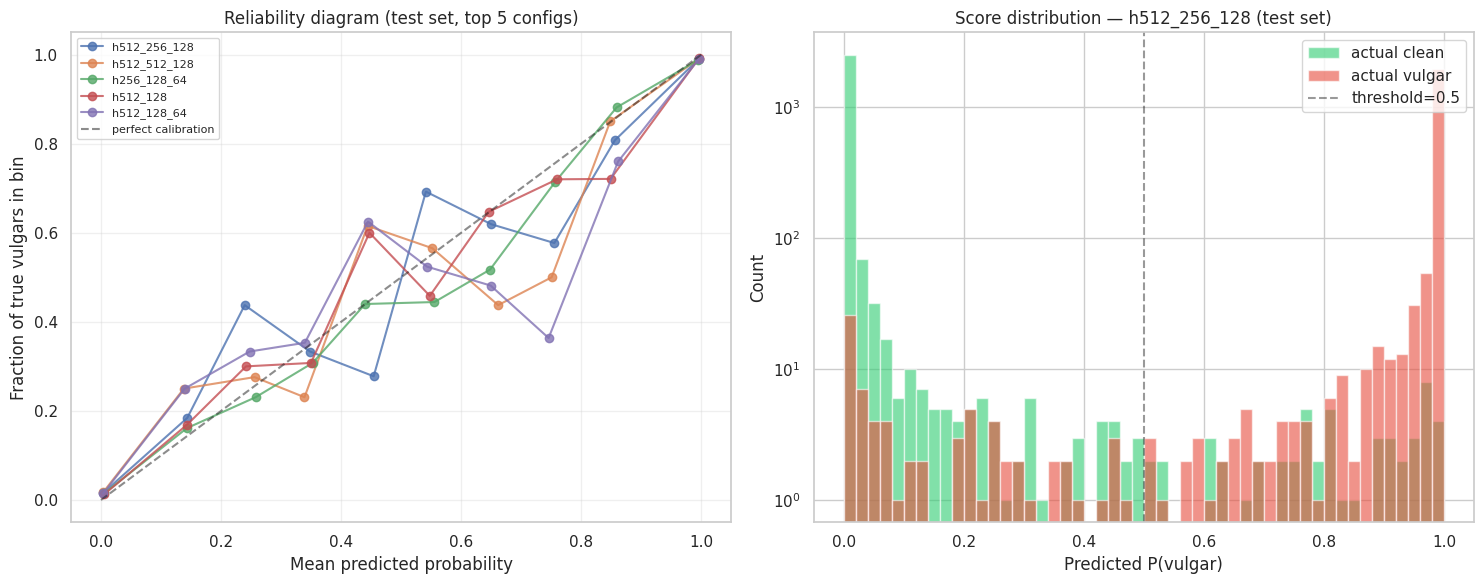

In [ ]:
from sklearn.calibration import calibration_curve

# Top 5 configs by combined score
top5 = ranked.head(5)["config"].tolist() if "ranked" in dir() else list(sweep_models.keys())[:5]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Reliability diagram (calibration curve)
ax = axes[0]
for name in top5:
    proba = proba_test[name]
    # 10 bins of equal predicted probability
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac_pos, marker="o", linewidth=1.5, label=name, alpha=0.8)
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="perfect calibration")
ax.set_title("Reliability diagram (test set, top 5 configs)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of true vulgars in bin")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)

# Score histogram for winner — shows how confident the model is on average
ax = axes[1]
proba = proba_test[winner_name]
ax.hist(proba[y_test == 0], bins=50, alpha=0.6, label="actual clean", color="#2ecc71", range=(0, 1))
ax.hist(proba[y_test == 1], bins=50, alpha=0.6, label="actual vulgar", color="#e74c3c", range=(0, 1))
ax.set_title(f"Score distribution — {winner_name} (test set)")
ax.set_xlabel("Predicted P(vulgar)")
ax.set_ylabel("Count")
ax.set_yscale("log")
ax.axvline(x=0.5, color="black", linestyle="--", alpha=0.4, label="threshold=0.5")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Brier score = mean squared error between predicted probability and binary truth
# Lower = better calibrated. Range 0 (perfect) to 1 (worst).
from sklearn.metrics import brier_score_loss

cal_rows = []
for name in sweep_models.keys():
    proba = proba_test[name]
    bs = brier_score_loss(y_test, proba)
    # ECE — Expected Calibration Error (avg |confidence - accuracy| over bins)
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="uniform")
    bin_counts = np.histogram(proba, bins=np.linspace(0, 1, 11))[0]
    used_bins = bin_counts[bin_counts > 0]
    if len(used_bins) == len(frac_pos):
        ece = np.average(np.abs(frac_pos - mean_pred), weights=used_bins)
    else:
        ece = float("nan")
    cal_rows.append({"config": name, "brier_score": bs, "ECE": ece})

cal_df = pd.DataFrame(cal_rows).set_index("config").sort_values("brier_score")
print("Calibration metrics (lower is better):\n")
print(cal_df.round(4).to_string())
print("\nBrier score: MSE between predicted prob and 0/1 truth.")
print("ECE:         avg |predicted prob - true frequency| weighted by bin size.")

Calibration metrics (lower is better):

               brier_score     ECE
config                            
h512_128            0.0206  0.0094
h512_256_128        0.0210  0.0132
h512_512_128        0.0217  0.0138
h512_128_e5         0.0220  0.0182
h1024_256_128       0.0224  0.0170
h256_128_64         0.0225  0.0102
h512_128_64         0.0229  0.0145
h256_128            0.0233  0.0118
h512                0.0314  0.0069
h256_d05            0.0350  0.0093
h256                0.0358  0.0108
h256_d01            0.0373  0.0094
h128                0.0384  0.0124
h64                 0.0393  0.0075

Brier score: MSE between predicted prob and 0/1 truth.
ECE:         avg |predicted prob - true frequency| weighted by bin size.
